# 23.1 · Perceptrons, loss and backpropagation

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain perceptrons, loss and backpropagation using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [05 · Image Processing](../../05-image-processing/README.md), [22 · Machine Learning for Vision](../../22-machine-learning-for-vision/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A neural network composes simple differentiable operations. A CNN shares small learned filters across image locations, exploiting local structure. Begin with an explicit small network and derivatives, then connect those operations to a framework training loop.

## 2. Intuition

A perceptron forms a weighted sum plus bias; a nonlinear activation lets multiple layers express more than one linear map. Forward propagation produces scores, a loss compares them with labels, and backpropagation applies the chain rule to obtain parameter gradients. The NumPy MLP includes explicit derivatives for tanh and softmax cross entropy.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 23
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\frac{\partial L}{\partial z_j}=p_j-y_j
$$

z is a class logit, p=softmax(z), y a one-hot label and L single-example cross entropy. For p=[0.2,0.8] and label class 1, the logit gradient is [0.2,−0.2]. Average this gradient over a mean-reduced batch.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
probabilities = np.array([0.2, 0.8])
target = np.array([0.0, 1.0])
logit_gradient = probabilities - target
assert np.isclose(logit_gradient.sum(), 0)
print(logit_gradient)

[ 0.2 -0.2]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Inspect the NumPy weight and bias gradients, then compare a fixed kernel through NumPy correlation and PyTorch conv2d. The final lesson trains a CNN with independent generated test samples.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def cnn(lesson, seed, amount):
    configure(seed)
    if lesson == 0:
        rng = np.random.default_rng(seed)
        x = np.r_[rng.normal(-1, 0.4, (24, 2)), rng.normal(1, 0.4, (24, 2))]
        y = np.r_[np.zeros(24, int), np.ones(24, int)]
        parameters, losses = n.mlp_train(x, y, learning_rate=0.15 * amount)
        return Result(
            "23 · Explicit neural-network backpropagation",
            {"Input features": x},
            curves={"Training cross entropy": losses},
            metrics={
                "training_accuracy": float((n.mlp_predict(x, parameters).argmax(1) == y).mean())
            },
            notes="Training accuracy on a constructed two-cluster problem is not held-out vision performance.",
        )
    if lesson == 1:
        image = n.gray(picture(seed))[:32, :32] / 255
        kernel = n.gaussian_kernel(3, 1)
        reference = n.correlate(image, kernel)
        tensor = torch.tensor(image, dtype=torch.float64)[None, None]
        result = F.conv2d(
            F.pad(tensor, (1, 1, 1, 1), mode="replicate"), torch.tensor(kernel)[None, None]
        ).numpy()[0, 0]
        return Result(
            "23 · Fixed filters become trainable CNN kernels",
            {"Input": image, "NumPy correlation": reference, "PyTorch conv2d": result},
            metrics={"maximum_error": float(abs(reference - result).max())},
        )
    return classification(lesson, seed, amount)

{
  "training_accuracy": 1.0
}
Training accuracy on a constructed two-cluster problem is not held-out vision performance.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import mlp_train

display(Code(inspect.getsource(mlp_train), language="python"))

def mlp_train(x, y, steps=150, learning_rate=0.2, seed=42):
    """One hidden tanh layer; explicit cross-entropy backpropagation."""
    rng = np.random.default_rng(seed)
    classes = int(max(y)) + 1
    w1 = rng.normal(0, 0.3, (x.shape[1], 12))
    b1 = np.zeros(12)
    w2 = rng.normal(0, 0.3, (12, classes))
    b2 = np.zeros(classes)
    onehot = np.eye(classes)[y]
    losses = []
    for _ in range(steps):
        hidden = np.tanh(x @ w1 + b1)
        probability = softmax(hidden @ w2 + b2)
        losses.append(float(-np.log(probability[np.arange(len(y)), y] + 1e-12).mean()))
        dz = (probability - onehot) / len(x)
        dw2, db2 = hidden.T @ dz, dz.sum(0)
        dh = (dz @ w2.T) * (1 - hidden**2)
        dw1, db1 = x.T @ dh, dh.sum(0)
        w1 -= learning_rate * dw1
        b1 -= learning_rate * db1
        w2 -= learning_rate * dw2
        b2 -= learning_rate * db2
    return (w1, b1, w2, b2), losses

## 8. Experiment

Remove the activation from a multilayer network and reason about which functions remain possible. Change stride and compute output size before running.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "training_accuracy": 1.0
  },
  "second_seed": {
    "training_accuracy": 1.0
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

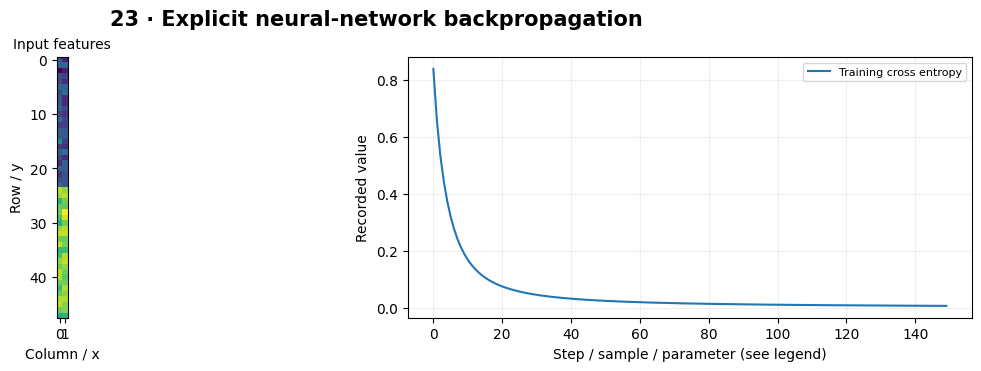

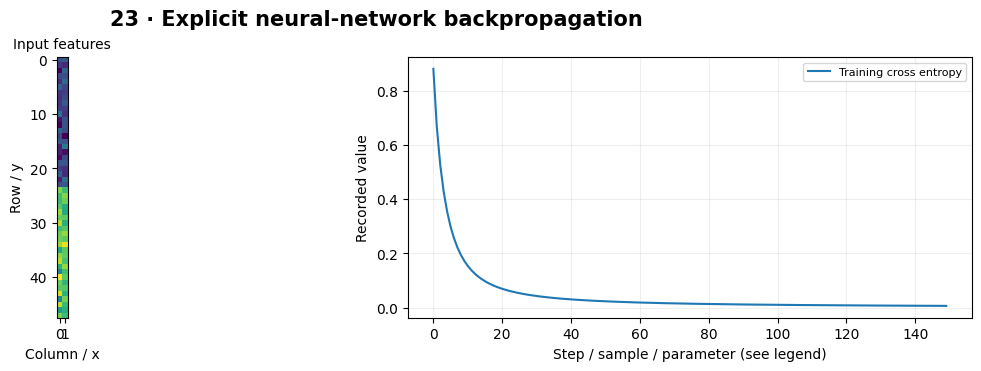

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Tiny CNN from First Principles**. Derive a tiny network update and compare fixed and learned filters. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Calling backward accumulates gradients unless they are cleared. A decreasing training loss does not prove generalization.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Remove the activation from a multilayer network and reason about which functions remain possible. Change stride and compute output size before running.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Implement a two-layer NumPy classifier with a finite-difference gradient check, then explain each corresponding PyTorch operation.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A perceptron forms a weighted sum plus bias; a nonlinear activation lets multiple layers express more than one linear map. Forward propagation produces scores, a loss compares them with labels, and backpropagation applies the chain rule to obtain parameter gradients. The NumPy MLP includes explicit derivatives for tanh and softmax cross entropy.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Convolution, padding and receptive fields** in this chapter.

[Primary reference](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)